In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import evaluation_lib as plot_gen
from tqdm import tqdm

testset_params = '../data/data/data/gas_tri_256/testpara.csv'
testparams = pd.read_csv(testset_params, index_col=0)
#load the data and parameters of the test set
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')
testset = testset_cmaps[:, 42:64] #only the central channels are present in the testset map
emulations = h5py.File("cmaps_emulations_small.h5", "r", swmr=True)

In [9]:
emucmaps_mp = emulations['PlanetMass']

In [10]:
emucmaps_mp.shape

(233, 20, 22, 250, 250)

In [45]:
from sklearn.decomposition import PCA
from tqdm import tqdm
expl_ratio = []

for i in tqdm(range(20)):
    pca = PCA(n_components=22)
    pca.fit(emucmaps_mp[20,i].reshape(22, -1))
    expl_ratio.append(pca.explained_variance_ratio_)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.46it/s]


In [46]:
expl_ratio = np.array(expl_ratio)

In [47]:
expl_ratio.shape

(20, 22)

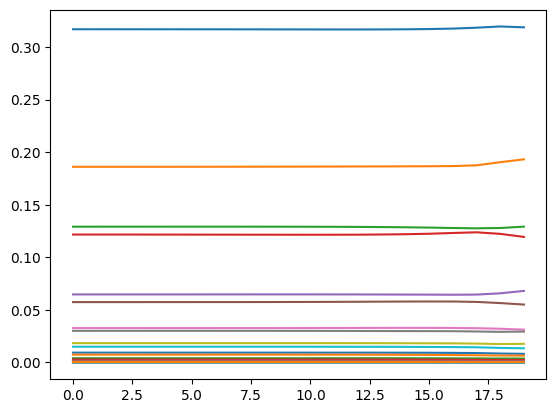

In [48]:
plt.plot(expl_ratio)

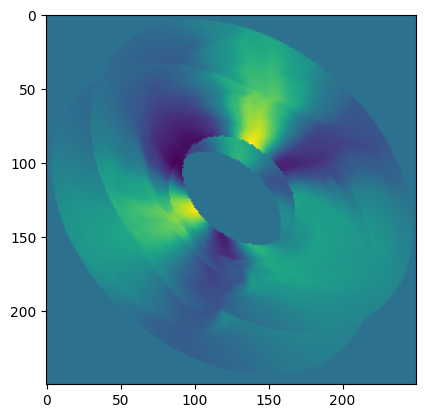

In [49]:
plt.imshow(pca.components_[2].reshape(250,250))